In [55]:
from tensorflow.keras.datasets import cifar10

# Wczytanie danych z podziałem na zbiór treningowy i testowy
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Sprawdzenie kształtu (wymiarów) danych
print("Kształt x_train:", x_train.shape) # Wynik: (50000, 32, 32, 3)
print("Kształt y_train:", y_train.shape) # Wynik: (50000, 1)

Kształt x_train: (50000, 32, 32, 3)
Kształt y_train: (50000, 1)


In [56]:
print("Kształt x_test:", x_test.shape) # Wynik: (50000, 32, 32, 3)
print("Kształt y_test:", y_test.shape)

Kształt x_test: (10000, 32, 32, 3)
Kształt y_test: (10000, 1)


In [57]:
y_test

array([[3],
       [8],
       [8],
       ...,
       [5],
       [1],
       [7]], dtype=uint8)

In [58]:
x_train[0][0]

array([[ 59,  62,  63],
       [ 43,  46,  45],
       [ 50,  48,  43],
       [ 68,  54,  42],
       [ 98,  73,  52],
       [119,  91,  63],
       [139, 107,  75],
       [145, 110,  80],
       [149, 117,  89],
       [149, 120,  93],
       [131, 103,  77],
       [125,  99,  76],
       [142, 115,  91],
       [144, 112,  86],
       [137, 105,  79],
       [129,  97,  71],
       [137, 106,  79],
       [134, 106,  76],
       [124,  97,  64],
       [139, 113,  78],
       [139, 112,  75],
       [133, 105,  69],
       [136, 105,  74],
       [139, 108,  77],
       [152, 120,  89],
       [163, 131, 100],
       [168, 136, 108],
       [159, 129, 102],
       [158, 130, 104],
       [158, 132, 108],
       [152, 125, 102],
       [148, 124, 103]], dtype=uint8)

In [59]:
print(x_train[0])

[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]


In [60]:
cifar10_classes = [
    'samolot', 'samochód', 'ptak', 'kot', 'jeleń',
    'pies', 'żaba', 'koń', 'statek', 'ciężarówka'
]

In [61]:
# Załóżmy, że sprawdzamy pierwszą etykietę ze zbioru
numerek = y_train[0][0]  # Przykładowo to będzie cyfra 6

# Używamy numerka, aby wyciągnąć słowo z listy
prawdziwa_klasa = cifar10_classes[numerek]

print(f"Sieć widzi cyfrę: {numerek}")
print(f"Dla nas to: {prawdziwa_klasa}")

Sieć widzi cyfrę: 6
Dla nas to: żaba


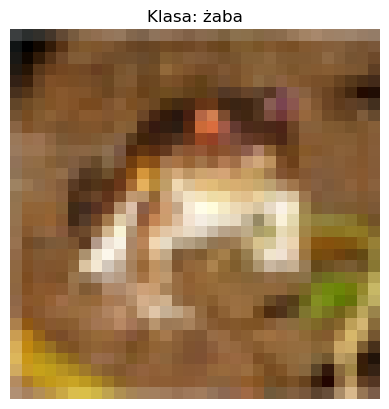

In [62]:
import matplotlib.pyplot as plt

# Lista klas dla przypomnienia
cifar10_classes = ['samolot', 'samochód', 'ptak', 'kot', 'jeleń', 
                   'pies', 'żaba', 'koń', 'statek', 'ciężarówka']

# Wybieramy indeks obrazka (np. 0, czyli pierwszy element)
indeks = 0

# Wyciągamy właściwy numer klasy z y_train
numer_klasy = y_train[indeks][0]

# Rysowanie
plt.imshow(x_train[indeks])
plt.title(f"Klasa: {cifar10_classes[numer_klasy]}")
plt.axis('off')  # Wyłącza osie liczbowe X i Y - przy zdjęciach tylko przeszkadzają
plt.show()

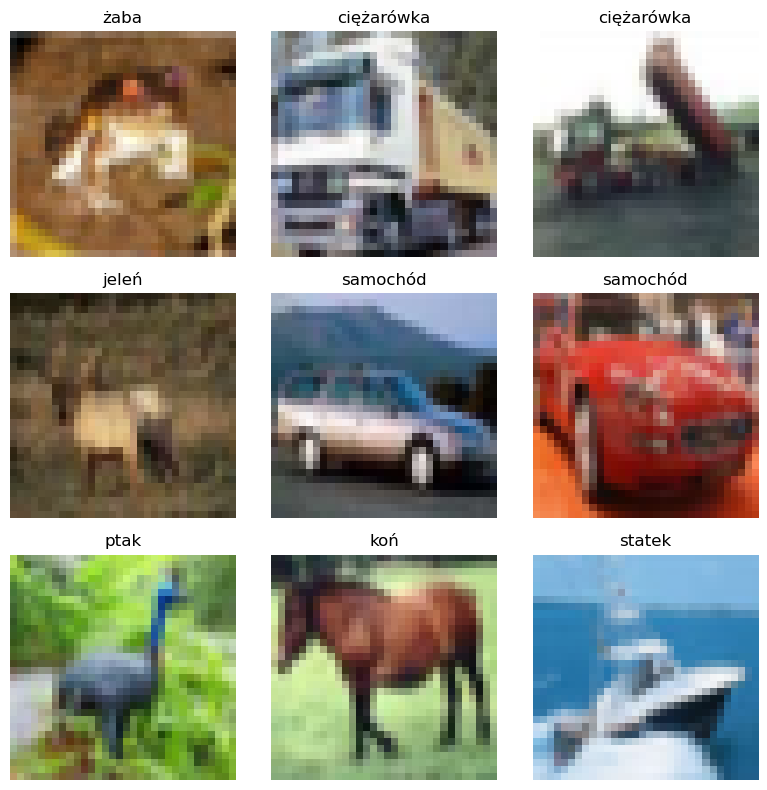

In [63]:
import matplotlib.pyplot as plt

# Ustawiamy rozmiar całego okna z wykresami
plt.figure(figsize=(8, 8))

for i in range(9):
    # Tworzymy siatkę 3 wiersze x 3 kolumny
    plt.subplot(3, 3, i + 1)
    
    # Wyświetlamy obrazek
    plt.imshow(x_train[i])
    
    # Pobieramy numer klasy i ustawiamy tytuł nad obrazkiem
    numer_klasy = y_train[i][0]
    plt.title(f"{cifar10_classes[numer_klasy]}")
    
    # Wyłączamy osie dla lepszej czytelności
    plt.axis('off')

# Optymalizuje odstępy między obrazkami
plt.tight_layout()
plt.show()

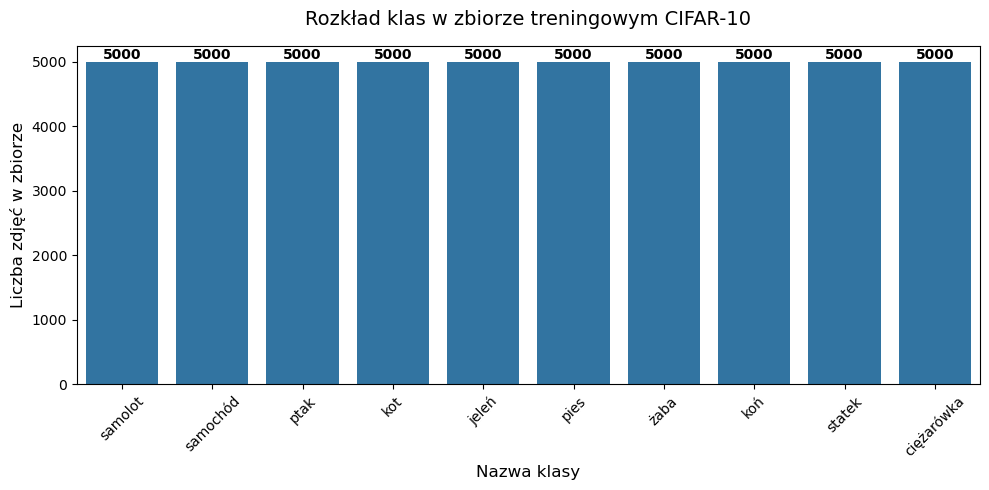

------------------------------
Szczegółowe podsumowanie:
------------------------------
Klasa  0 (samolot    ): 5000 zdjęć
Klasa  1 (samochód   ): 5000 zdjęć
Klasa  2 (ptak       ): 5000 zdjęć
Klasa  3 (kot        ): 5000 zdjęć
Klasa  4 (jeleń      ): 5000 zdjęć
Klasa  5 (pies       ): 5000 zdjęć
Klasa  6 (żaba       ): 5000 zdjęć
Klasa  7 (koń        ): 5000 zdjęć
Klasa  8 (statek     ): 5000 zdjęć
Klasa  9 (ciężarówka ): 5000 zdjęć


In [64]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Zliczamy wystąpienia każdej klasy w zbiorze treningowym
unikalne_klasy, liczebnosc = np.unique(y_train, return_counts=True)

# 2. Tworzymy wykres słupkowy
plt.figure(figsize=(10, 5))
# Mapujemy numery klas na ich polskie nazwy z zdefiniowanej wcześniej listy
nazwy_klas = [cifar10_classes[i] for i in unikalne_klasy]

sns.barplot(x=nazwy_klas, y=liczebnosc)

plt.title("Rozkład klas w zbiorze treningowym CIFAR-10", fontsize=14, pad=15)
plt.xlabel("Nazwa klasy", fontsize=12)
plt.ylabel("Liczba zdjęć w zbiorze", fontsize=12)
plt.xticks(rotation=45) # Obracamy napisy, żeby się nie nakładały

# Dodanie dokładnych wartości nad każdym słupkiem
for i, v in enumerate(liczebnosc):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 3. Wyświetlenie czystego podsumowania tekstowego
print("-" * 30)
print("Szczegółowe podsumowanie:")
print("-" * 30)
for k, l in zip(unikalne_klasy, liczebnosc):
    print(f"Klasa {k:2d} ({cifar10_classes[k]:11s}): {l} zdjęć")

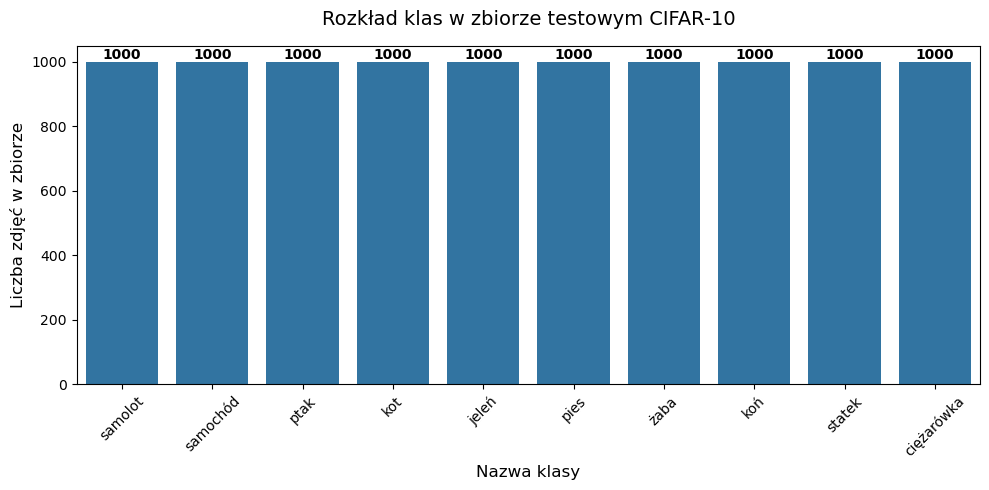

Klasy w zbiorze testowym:
samolot    : 1000 zdjęć
samochód   : 1000 zdjęć
ptak       : 1000 zdjęć
kot        : 1000 zdjęć
jeleń      : 1000 zdjęć
pies       : 1000 zdjęć
żaba       : 1000 zdjęć
koń        : 1000 zdjęć
statek     : 1000 zdjęć
ciężarówka : 1000 zdjęć


In [65]:
# Zliczamy wystąpienia w zbiorze testowym
unikalne_klasy_test, liczebnosc_test = np.unique(y_test, return_counts=True)

# Tworzymy wykres
plt.figure(figsize=(10, 5))
sns.barplot(x=nazwy_klas, y=liczebnosc_test)

plt.title("Rozkład klas w zbiorze testowym CIFAR-10", fontsize=14, pad=15)
plt.xlabel("Nazwa klasy", fontsize=12)
plt.ylabel("Liczba zdjęć w zbiorze", fontsize=12)
plt.xticks(rotation=45)

# Wartości nad słupkami
for i, v in enumerate(liczebnosc_test):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Klasy w zbiorze testowym:")
for k, l in zip(unikalne_klasy_test, liczebnosc_test):
    print(f"{cifar10_classes[k]:11s}: {l} zdjęć")

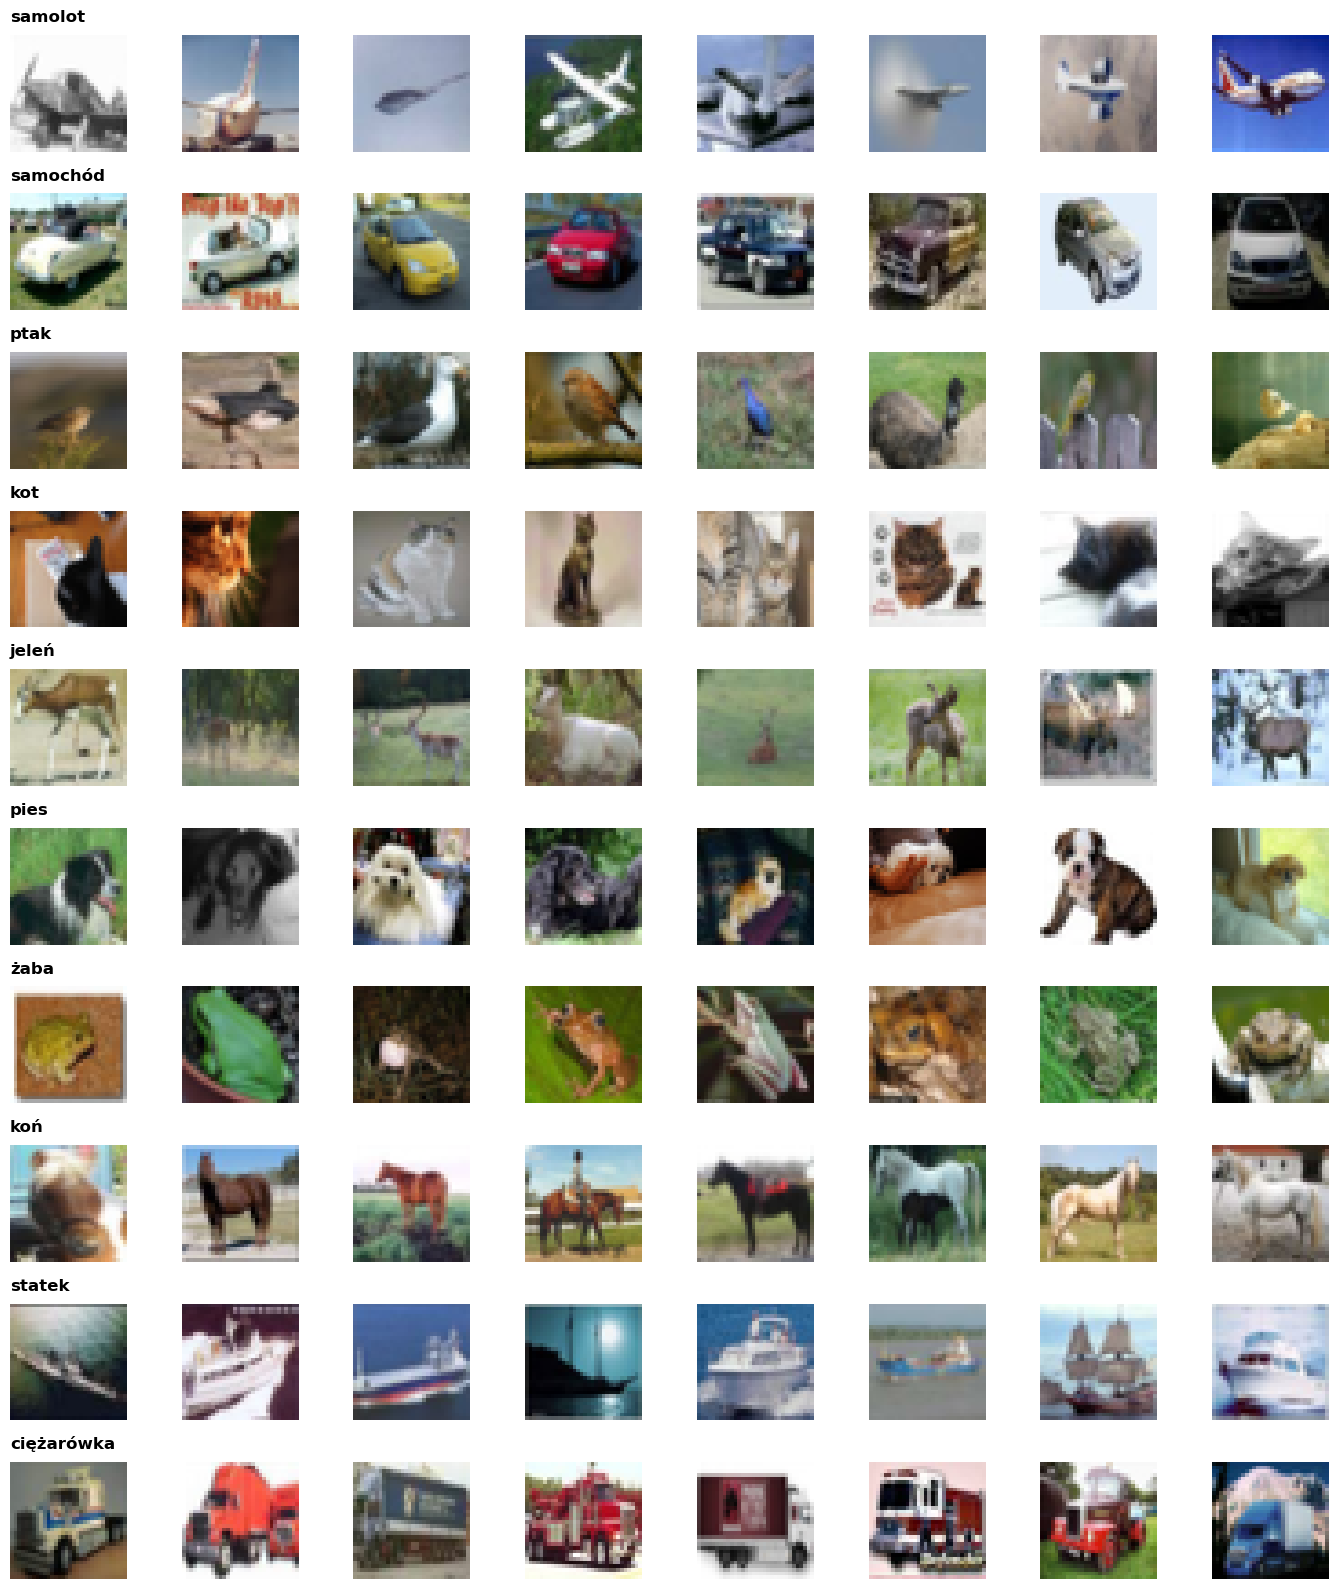

In [66]:
import numpy as np
import matplotlib.pyplot as plt

# Ustawienia siatki: 10 klas i 8 przykładów dla każdej
liczba_klas = 10
przyklady_na_klase = 8

# Tworzymy duży wykres (10 wierszy, 8 kolumn)
fig, axes = plt.subplots(liczba_klas, przyklady_na_klase, figsize=(14, 16))

for i in range(liczba_klas):
    # 1. Znajdujemy wszystkie indeksy zdjęć należących do klasy 'i'
    indeksy_klasy = np.where(y_train == i)[0]
    
    # 2. Wybieramy 8 losowych indeksów (bez powtórzeń)
    losowe_indeksy = np.random.choice(indeksy_klasy, przyklady_na_klase, replace=False)
    
    for j, idx in enumerate(losowe_indeksy):
        ax = axes[i, j]
        ax.imshow(x_train[idx])
        ax.axis('off') # Wyłączamy osie liczbowe
        
        # 3. W pierwszej kolumnie dodajemy polską nazwę klasy obok obrazka
        if j == 0:
            ax.set_title(cifar10_classes[i], loc='left', fontsize=12, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

In [67]:
import numpy as np

# --- 1. ZBIÓR TRENINGOWY ---
# Oś 0: liczba obrazków, Oś 1: wysokość, Oś 2: szerokość
# Wyciągamy średnią i odchylenie "po tych trzech osiach", zostawiając Oś 3 (kanały RGB)
srednia_rgb_train = np.mean(x_train, axis=(0, 1, 2))
odchylenie_rgb_train = np.std(x_train, axis=(0, 1, 2))

print("=== STATYSTYKI ZBIORU TRENINGOWEGO (x_train) ===")
print("Średnia wartość pikseli (zakres 0-255):")
print(f"R (Czerwony): {srednia_rgb_train[0]:.2f}")
print(f"G (Zielony):  {srednia_rgb_train[1]:.2f}")
print(f"B (Niebieski): {srednia_rgb_train[2]:.2f}")

print("\nOdchylenie standardowe (zakres 0-255):")
print(f"R (Czerwony): {odchylenie_rgb_train[0]:.2f}")
print(f"G (Zielony):  {odchylenie_rgb_train[1]:.2f}")
print(f"B (Niebieski): {odchylenie_rgb_train[2]:.2f}")


# --- 2. ZBIÓR TESTOWY ---
# Wykonujemy analogiczne obliczenia dla x_test
srednia_rgb_test = np.mean(x_test, axis=(0, 1, 2))
odchylenie_rgb_test = np.std(x_test, axis=(0, 1, 2))

print("\n\n=== STATYSTYKI ZBIORU TESTOWEGO (x_test) ===")
print("Średnia wartość pikseli (zakres 0-255):")
print(f"R (Czerwony): {srednia_rgb_test[0]:.2f}")
print(f"G (Zielony):  {srednia_rgb_test[1]:.2f}")
print(f"B (Niebieski): {srednia_rgb_test[2]:.2f}")

print("\nOdchylenie standardowe (zakres 0-255):")
print(f"R (Czerwony): {odchylenie_rgb_test[0]:.2f}")
print(f"G (Zielony):  {odchylenie_rgb_test[1]:.2f}")
print(f"B (Niebieski): {odchylenie_rgb_test[2]:.2f}")

=== STATYSTYKI ZBIORU TRENINGOWEGO (x_train) ===
Średnia wartość pikseli (zakres 0-255):
R (Czerwony): 125.31
G (Zielony):  122.95
B (Niebieski): 113.87

Odchylenie standardowe (zakres 0-255):
R (Czerwony): 62.99
G (Zielony):  62.09
B (Niebieski): 66.70


=== STATYSTYKI ZBIORU TESTOWEGO (x_test) ===
Średnia wartość pikseli (zakres 0-255):
R (Czerwony): 126.02
G (Zielony):  123.71
B (Niebieski): 114.85

Odchylenie standardowe (zakres 0-255):
R (Czerwony): 62.90
G (Zielony):  61.94
B (Niebieski): 66.71


In [68]:
# 1. Zmiana typu danych (Casting) na zmiennoprzecinkowe
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

# 2. Normalizacja (skalowanie pikseli do przedziału 0.0 - 1.0)
x_train = x_train / 255.0
x_test = x_test / 255.0

In [69]:
x_test

array([[[[0.61960787, 0.4392157 , 0.19215687],
         [0.62352943, 0.43529412, 0.18431373],
         [0.64705884, 0.45490196, 0.2       ],
         ...,
         [0.5372549 , 0.37254903, 0.14117648],
         [0.49411765, 0.35686275, 0.14117648],
         [0.45490196, 0.33333334, 0.12941177]],

        [[0.59607846, 0.4392157 , 0.2       ],
         [0.5921569 , 0.43137255, 0.15686275],
         [0.62352943, 0.44705883, 0.1764706 ],
         ...,
         [0.53333336, 0.37254903, 0.12156863],
         [0.49019608, 0.35686275, 0.1254902 ],
         [0.46666667, 0.34509805, 0.13333334]],

        [[0.5921569 , 0.43137255, 0.18431373],
         [0.5921569 , 0.42745098, 0.12941177],
         [0.61960787, 0.43529412, 0.14117648],
         ...,
         [0.54509807, 0.38431373, 0.13333334],
         [0.50980395, 0.37254903, 0.13333334],
         [0.47058824, 0.34901962, 0.12941177]],

        ...,

        [[0.26666668, 0.4862745 , 0.69411767],
         [0.16470589, 0.39215687, 0.5803922 ]

In [70]:
x_train

array([[[[0.23137255, 0.24313726, 0.24705882],
         [0.16862746, 0.18039216, 0.1764706 ],
         [0.19607843, 0.1882353 , 0.16862746],
         ...,
         [0.61960787, 0.5176471 , 0.42352942],
         [0.59607846, 0.49019608, 0.4       ],
         [0.5803922 , 0.4862745 , 0.40392157]],

        [[0.0627451 , 0.07843138, 0.07843138],
         [0.        , 0.        , 0.        ],
         [0.07058824, 0.03137255, 0.        ],
         ...,
         [0.48235294, 0.34509805, 0.21568628],
         [0.46666667, 0.3254902 , 0.19607843],
         [0.47843137, 0.34117648, 0.22352941]],

        [[0.09803922, 0.09411765, 0.08235294],
         [0.0627451 , 0.02745098, 0.        ],
         [0.19215687, 0.10588235, 0.03137255],
         ...,
         [0.4627451 , 0.32941177, 0.19607843],
         [0.47058824, 0.32941177, 0.19607843],
         [0.42745098, 0.28627452, 0.16470589]],

        ...,

        [[0.8156863 , 0.6666667 , 0.3764706 ],
         [0.7882353 , 0.6       , 0.13333334]

In [71]:
y_train

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

In [72]:
y_test

array([[3],
       [8],
       [8],
       ...,
       [5],
       [1],
       [7]], dtype=uint8)

In [73]:
import os
import numpy as np

# 1. Tworzymy folder 'data', jeśli jeszcze nie istnieje (exist_ok=True zapobiega błędom)
os.makedirs('data', exist_ok=True)

# 2. Definiujemy bezpieczną ścieżkę do pliku
sciezka_do_pliku = os.path.join('data', 'cifar10_preprocessed.npz')

# 3. Zapisywanie danych ze wbudowaną kompresją we wskazanym miejscu
np.savez_compressed(
    sciezka_do_pliku, 
    x_train=x_train, 
    y_train=y_train, 
    x_test=x_test, 
    y_test=y_test
)

print(f"Dane zapisane do pliku: {sciezka_do_pliku}")

Dane zapisane do pliku: data\cifar10_preprocessed.npz
